#### Importamos todas las libreriras que vamos a utilizar

In [22]:
import pandas as pd
from pandas.api.types import CategoricalDtype
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
from scipy.stats import describe
#import requests

### Acerca de: Inside Airbnb es un proyecto impulsado por una misión que proporciona datos y defensa sobre el impacto de Airbnb en las comunidades residenciales.Trabajamos hacia una visión en la que las comunidades estén empoderadas con datos e información para comprender, decidir y controlar el papel del alquiler de viviendas residenciales a turistas.

Generamos el dataset Airbnb en Buenos Aires

In [23]:
df = pd.read_csv("C:/Users/Gonzalo Rodriguez/OneDrive/Documentos/Especializacion en IA -CEIA/Analisis de datos/TP/Buenos_Aires_AIRBNB.csv")

Primera idea de que tiene el data set

In [24]:
df.head()

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,7270,¡¡Great Loft in Palermo Hollywood!!,18822,Toni,Palermo,-34.58241,-58.43382,Entire home/apt,2033,20,14,30-04-2018,0.15,1,363
1,11508,Amazing Luxurious Apt-Palermo Soho,42762,Candela,Palermo,-34.58225,-58.42460,Entire home/apt,3588,2,25,13-08-2019,0.28,1,281
2,12463,Room in Recoleta - awesome location,48799,Matt,Recoleta,-34.59761,-58.39468,Private room,1435,1,20,11-12-2017,0.17,1,365
3,13095,Standard Room at Palermo Viejo B&B,50994,Ariel,Palermo,-34.59382,-58.42994,Private room,2691,1,1,18-12-2018,0.09,7,360
4,13096,Standard Room in Palermo Viejo B&B,50994,Ariel,Palermo,-34.59398,-58.42853,Private room,2691,1,0,NaN,NaN,7,360


#### Hacemos un shape y vemos que el data set tiene 22877 observaciones distribuida en 15 variables

In [25]:
df.shape

(22877, 15)

Informacion de las variables

In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 22877 entries, 0 to 22876
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              22877 non-null  int64  
 1   name                            22867 non-null  str    
 2   host_id                         22877 non-null  int64  
 3   host_name                       22854 non-null  str    
 4   neighbourhood                   22877 non-null  str    
 5   latitude                        22877 non-null  float64
 6   longitude                       22877 non-null  float64
 7   room_type                       22877 non-null  str    
 8   price                           22877 non-null  int64  
 9   minimum_nights                  22877 non-null  int64  
 10  number_of_reviews               22877 non-null  int64  
 11  last_review                     16432 non-null  str    
 12  reviews_per_month               16432 non-n

Variables numericas

In [27]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,2.287700e+04,2.287700e+04,22877.000000,22877.000000,22877.000000,22877.000000,22877.000000,16432.000000,22877.000000,22877.000000
mean,2.487670e+07,9.739731e+07,-34.592534,-58.416364,3214.630196,5.653233,15.482974,1.266434,6.296062,202.064912
std,1.191191e+07,9.274044e+07,0.018304,0.029937,12364.429880,21.513176,31.268565,1.440429,14.748998,134.161675
min,7.270000e+03,2.616000e+03,-34.688950,-58.530200,120.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,1.631899e+07,1.363528e+07,-34.603400,-58.435630,1196.000000,1.000000,0.000000,0.250000,1.000000,83.000000
50%,2.856388e+07,6.212518e+07,-34.591830,-58.415950,1973.000000,3.000000,4.000000,0.760000,1.000000,180.000000
75%,3.454449e+07,1.713546e+08,-34.581970,-58.392220,2990.000000,4.000000,16.000000,1.810000,4.000000,343.000000
max,4.035243e+07,3.118884e+08,-34.532720,-58.354880,597865.000000,1125.000000,600.000000,37.580000,105.000000,365.000000


Variables Numericas: Tenemos 13 variables numericas. 

| Variable | Traducción | Descripción | Tipo | ¿Ordinal? | Observación |
|---|---|---|---|---|---|
| `id` | Identificador del alojamiento | ID único de cada publicación | Discreta | No | Identificador, sin sentido aritmético |
| `host_id` | Identificador del anfitrión | ID único del anfitrión | Discreta | No | Identificador, sin sentido aritmético |
| `latitude` | Latitud | Coordenada geográfica norte-sur | Continua | No | Coordenada geoespacial |
| `longitude` | Longitud | Coordenada geográfica este-oeste | Continua | No | Coordenada geoespacial |
| `price` | Precio por noche | Precio en pesos argentinos por noche | Continua | No | Variable objetivo de interés principal |
| `minimum_nights` | Noches mínimas | Cantidad mínima de noches para reservar | Discreta | No | Toma valores enteros positivos |
| `number_of_reviews` | Número de reseñas | Total acumulado de reseñas | Discreta | No | Toma valores enteros positivos |
| `reviews_per_month` | Reseñas por mes | Promedio mensual de reseñas | Continua | No | Puede tomar cualquier valor decimal |
| `calculated_host_listings_count` | Publicaciones del anfitrión | Número de alojamientos del anfitrión | Discreta | No | Toma valores enteros positivos |
| `availability_365` | Disponibilidad anual | Días disponibles en los próximos 365 días | Discreta | No | Valores enteros entre 0 y 365 |

In [28]:
df.describe(include=['object'])

C:\Users\Gonzalo Rodriguez\AppData\Local\Temp\ipykernel_21404\3011300674.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include=['object'])


,name,host_name,neighbourhood,room_type,last_review
count,22867,22854,22877,22877,16432
unique,22129,3706,48,4,1326
top,Departamento en Recoleta,Maria,Palermo,Entire home/apt,18-11-2019
freq,26,343,6934,17389,654


| Variable | Traducción | Descripción | Tipo | ¿Ordinal? | Observación |
|---|---|---|---|---|---|
| `name` | Nombre del alojamiento | Título de la publicación en Airbnb | Nominal | No | Texto libre, alta cardinalidad |
| `host_name` | Nombre del anfitrión | Nombre público del anfitrión | Nominal | No | Texto libre, alta cardinalidad |
| `neighbourhood` | Barrio | Barrio donde se ubica el alojamiento | Nominal | No | Cantidad acotada de valores únicos |
| `room_type` | Tipo de habitación | Tipo de alojamiento ofrecido (casa completa, habitación privada, etc.) | Nominal | No | Pocos valores únicos |
| `last_review` | Última reseña | Fecha de la última reseña recibida |Nominal| No | Variable temporal |

In [49]:
df.isna().mean() * 100

id                                 0.000000
name                               0.043712
host_id                            0.000000
host_name                          0.100538
neighbourhood                      0.000000
latitude                           0.000000
longitude                          0.000000
room_type                          0.000000
price                              0.000000
minimum_nights                     0.000000
number_of_reviews                  0.000000
last_review                       28.172400
reviews_per_month                 28.172400
calculated_host_listings_count     0.000000
availability_365                   0.000000
dtype: float64

Contamos cantidad de nulos

In [31]:
df.isnull().sum(axis=0)

id                                   0
name                                10
host_id                              0
host_name                           23
neighbourhood                        0
latitude                             0
longitude                            0
room_type                            0
price                                0
minimum_nights                       0
number_of_reviews                    0
last_review                       6445
reviews_per_month                 6445
calculated_host_listings_count       0
availability_365                     0
dtype: int64

### Vamos a realizar graficos para observar comportamientos de las variables

Realicemos un pair plot de todas las variables numericas para ver su distribucion y realacion

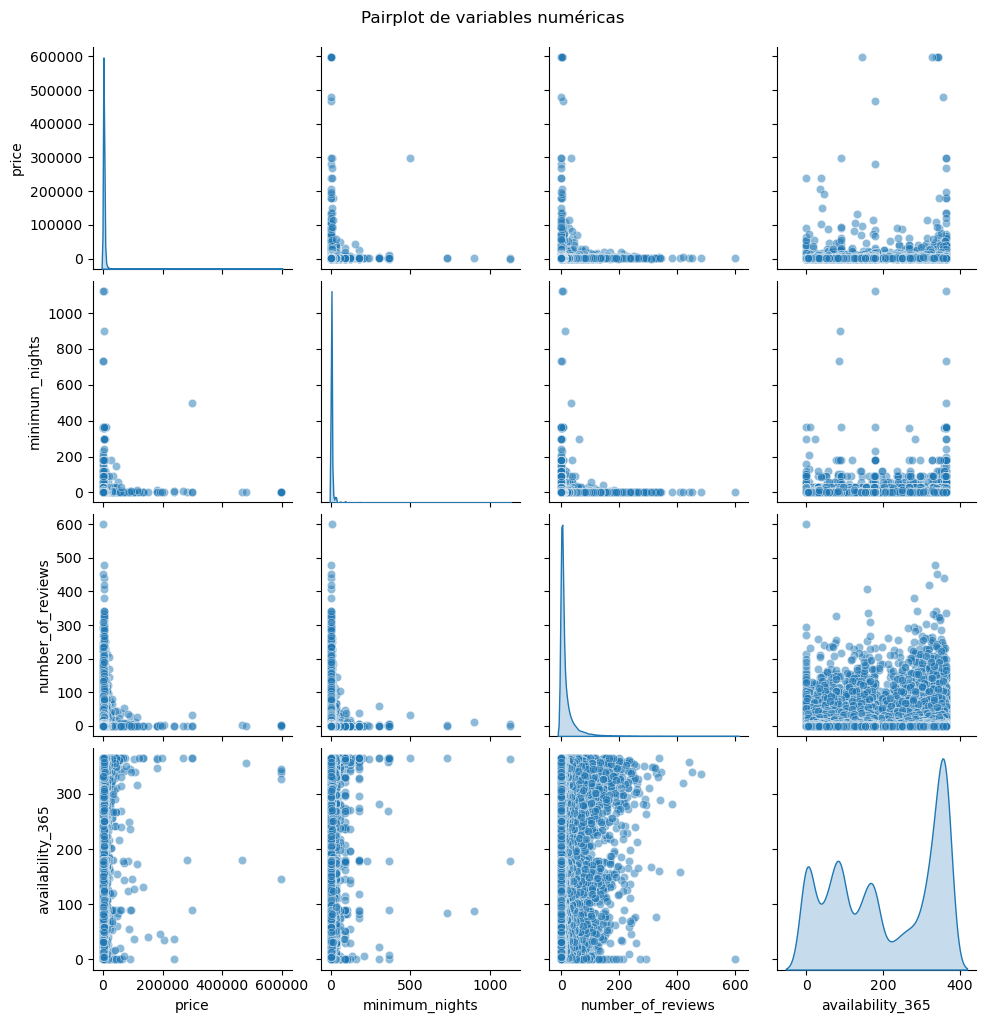

In [104]:
cols = ['price', 'minimum_nights', 'number_of_reviews', 'availability_365']

sns.pairplot(df[cols].dropna(), diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle('Pairplot de variables numéricas', y=1.02)
plt.show()

Se observa en las variable **Price**, **numer_of_reviews** y **number_of_nights** que tienen una distribucion con un cola muy larga hacia la derecha lo que dificulta observar algun patron. Por ejemplo la variable number of night esta la mayoria en un valor menor a 30.

Vamos a analizar mas en profundiad la varible **Price** hay algunos valores muy dispares por ejemplo la valor minimo es 120 y el maxmo es 597865, la media es 3214.63 y la mediana es 1973. Se observa en la desviacion estandar STD= 12364, loq ue indica mucha dispersion. Pero al no haber tanta diferencia entre media y medina es que los valores con numero muy grande son poca cantidad

In [100]:
Valor_mayor_10000 = df[df['price']>70000].count()

Obsrvamos que los valores de Price  mayor a 70000 son solo 46 muestran que solo representeane el 0,2%

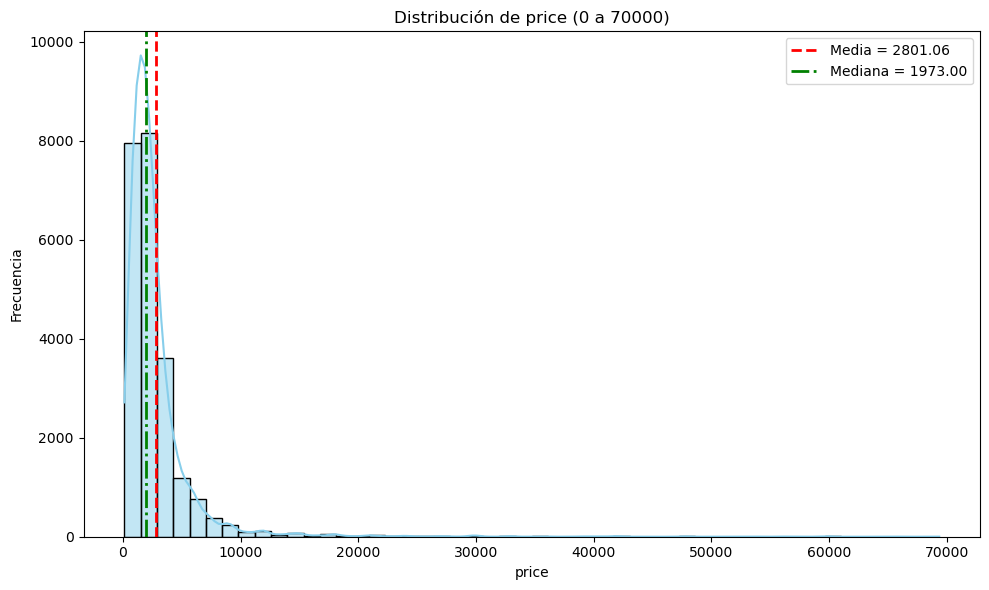

In [101]:
price = pd.to_numeric(df["price"], errors="coerce")
price_clipped = price[(price >= 0) & (price <= 70000)]

mean = price_clipped.mean()
median = price_clipped.median()

plt.figure(figsize=(10, 6))
sns.histplot(price_clipped.dropna(), bins=50, kde=True, color='skyblue')

plt.axvline(mean, color='red', linestyle='--', linewidth=2, label=f'Media = {mean:.2f}')
plt.axvline(median, color='green', linestyle='-.', linewidth=2, label=f'Mediana = {median:.2f}')

plt.title("Distribución de price (0 a 70000)")
plt.xlabel("price")
plt.ylabel("Frecuencia")
plt.legend()
plt.tight_layout()
plt.show()

Slice del dataframe para poder hacer un grafico de cantidad de Airbnb por barrio (mostrando solo los mas populares)

In [105]:
barrios_id_df = df[["neighbourhood", "id"]]
barrios_id_df

,neighbourhood,id
0,Palermo,7270
1,Palermo,11508
2,Recoleta,12463
3,Palermo,13095
4,Palermo,13096
...,...,...
22872,Parque Patricios,40350240
22873,Villa Urquiza,40351237
22874,Palermo,40351485
22875,Palermo,40351815


Agrupar por barrio y agregar la variable de cantidad de veces que el barrio es observado

In [33]:
barrios_id_df =  barrios_id_df.groupby(['neighbourhood'])["id"].count().reset_index(name='Count').sort_values(['Count'], ascending=False)
barrios_id_df =  barrios_id_df[barrios_id_df["Count"] > 1000]
barrios_id_df

,neighbourhood,Count
20,Palermo,6934
27,Recoleta,3687
31,San Nicolas,1316
28,Retiro,1159
2,Balvanera,1100
4,Belgrano,1048


Otro slice para quedarnos con los barrios con mas de 1000 Airbnb

In [34]:
top_barrios_df = df[df["neighbourhood"].isin(["Palermo", "Recoleta", "San Nicolas", "Belgrano", "Retiro", "Monserrat", "Balvanera", "Almagro"])]

Grafico copiado de la clase

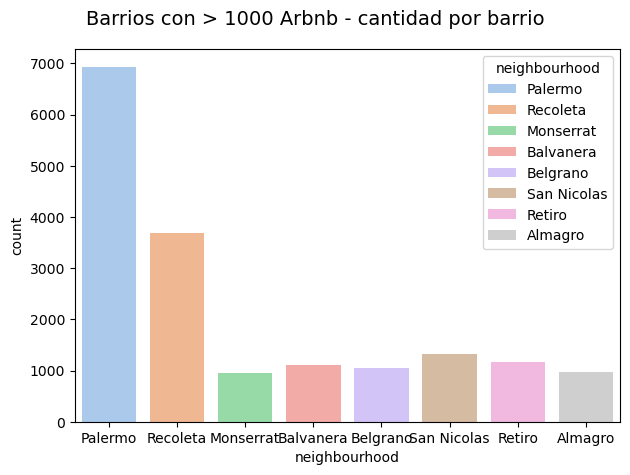

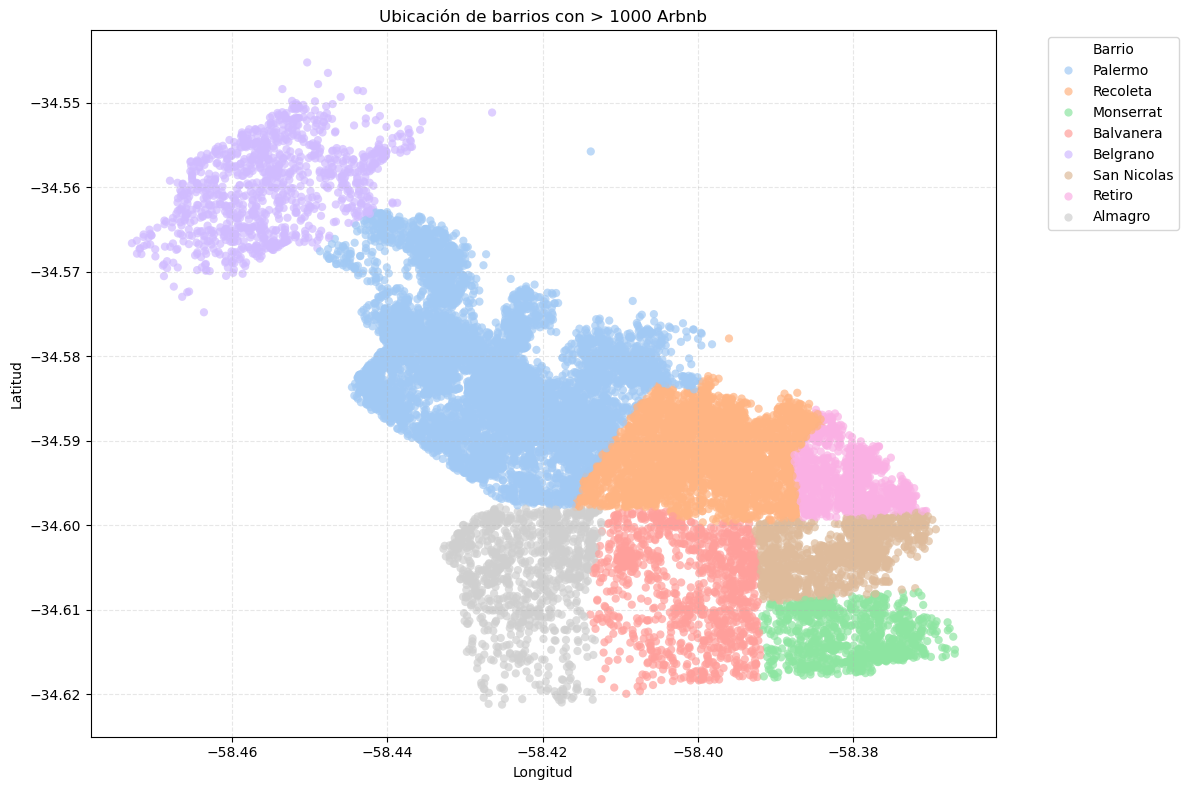

In [125]:
sns.countplot(x="neighbourhood", data=top_barrios_df, hue="neighbourhood", palette='pastel', legend='brief')

plt.suptitle('Barrios con > 1000 Arbnb - cantidad por barrio', fontsize=14)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
sns.scatterplot(data=top_barrios_df, x='longitude', y='latitude', hue='neighbourhood', palette='pastel', alpha=0.7, s=35, edgecolor='none')
plt.title('Ubicación de barrios con > 1000 Arbnb')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Barrio')
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

Grafico de disponibilidad

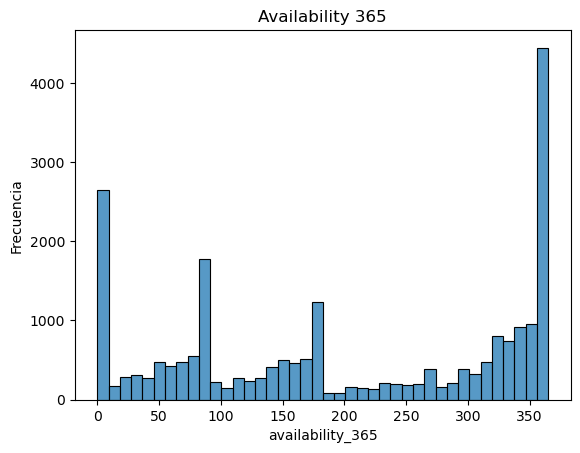

In [41]:
sns.histplot(df["availability_365"].dropna(), bins=40)
plt.title("Availability 365")
plt.xlabel("availability_365")
plt.ylabel("Frecuencia")
plt.show()

Cantidad de reviews vs disponibilidad

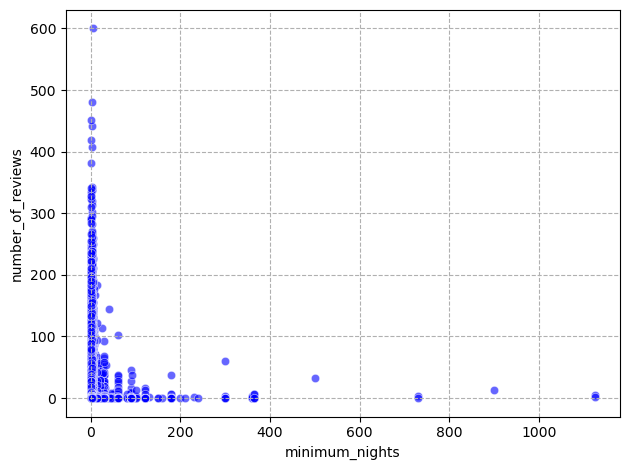

In [44]:

sns.scatterplot(data=df, x='minimum_nights', y='number_of_reviews', color='b',alpha=0.6)
	
plt.grid(ls='--')
plt.title('')
plt.tight_layout()
plt.show()

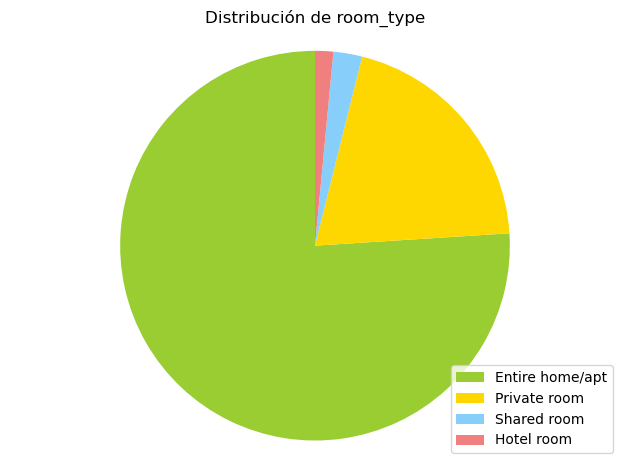

In [46]:
#plot_pie(Airbnb_df, "room_type")
labels = df["room_type"].value_counts().index
colors = ['yellowgreen', 'gold', 'lightskyblue', 'lightcoral']
patches, texts = plt.pie(df["room_type"].value_counts(), colors=colors, startangle=90)
plt.title(f'Distribución de room_type')
plt.legend(patches, labels, loc="best")
# Set aspect ratio to be equal so that pie is drawn as a circle.
plt.axis('equal')
plt.tight_layout()
plt.show()

Ralizamos una matriz de correlacion entre las variables numericas

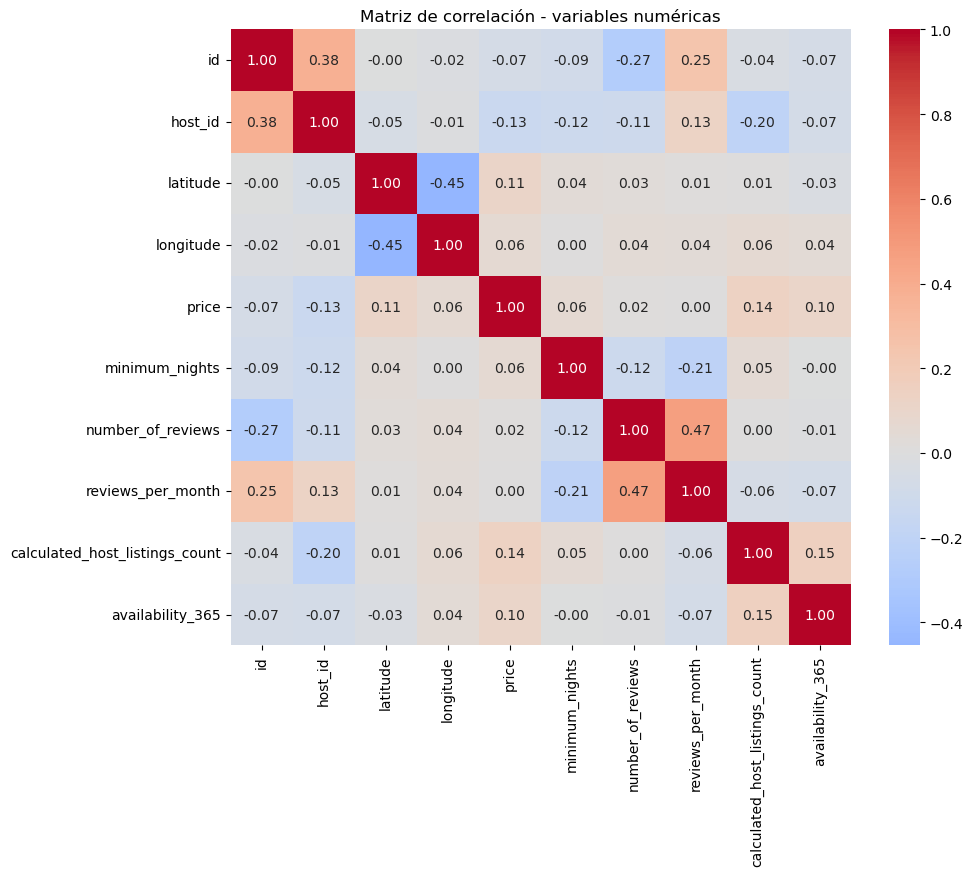

In [108]:
numerical_cols = df.select_dtypes(include=['number']).columns
corr = df[numerical_cols].corr(method='kendall')

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlación - variables numéricas")
plt.show()

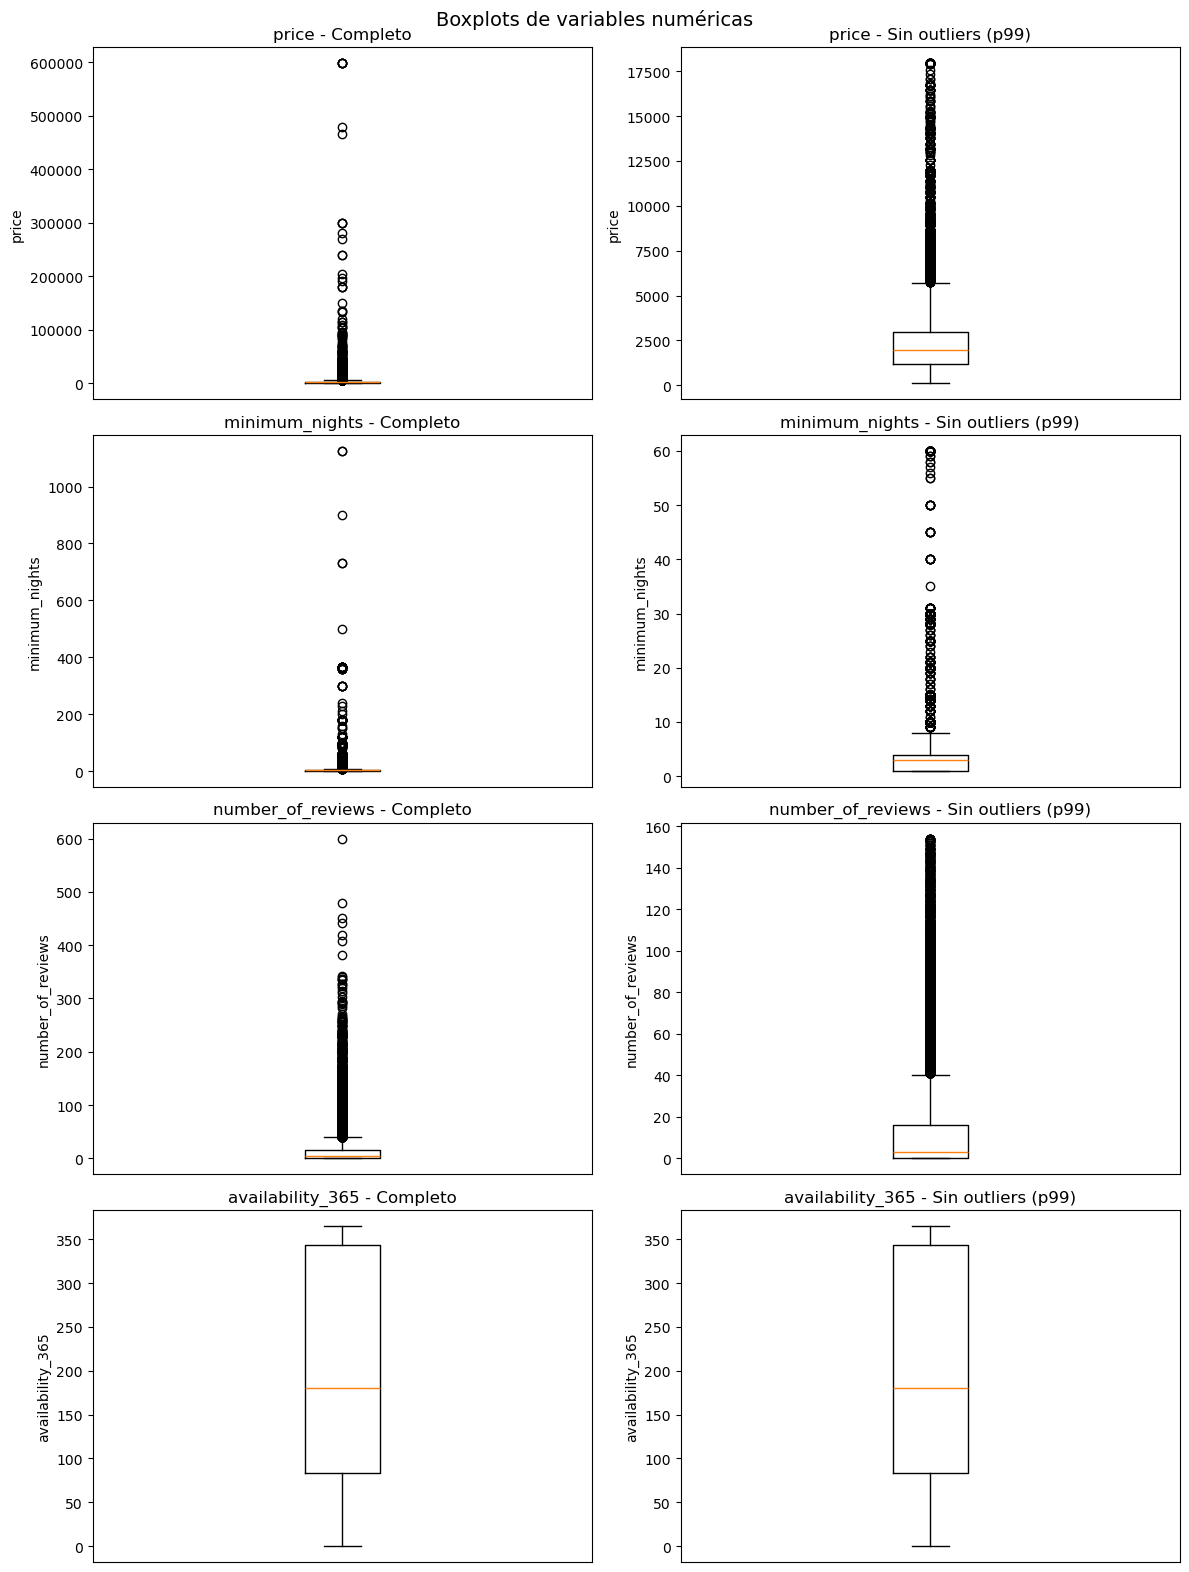

In [114]:
variables = ['price', 'minimum_nights', 'number_of_reviews', 'availability_365']

fig, axes = plt.subplots(4, 2, figsize=(12, 16))

for i, var in enumerate(variables):
    
    # Columna izquierda: datos completos
    axes[i, 0].boxplot(df[var].dropna())
    axes[i, 0].set_title(f'{var} - Completo')
    axes[i, 0].set_ylabel(var)
    axes[i, 0].set_xticks([])
    
    # Columna derecha: sin outliers extremos (p99)
    p99 = df[var].quantile(0.99)
    axes[i, 1].boxplot(df[var][df[var] <= p99].dropna())
    axes[i, 1].set_title(f'{var} - Sin outliers (p99)')
    axes[i, 1].set_ylabel(var)
    axes[i, 1].set_xticks([])

plt.suptitle('Boxplots de variables numéricas', fontsize=14)
plt.tight_layout()
plt.show()

Vamos si hay una realacion entre los precios elevados y la cantidad de dias minimos

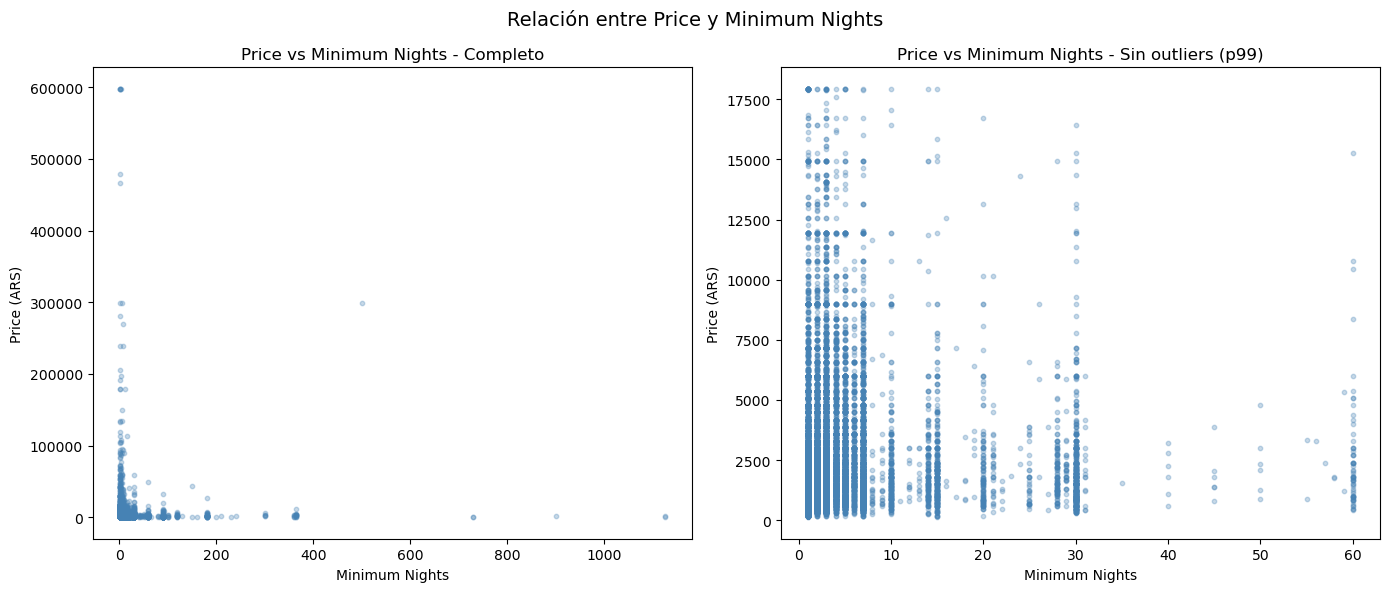

In [126]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Izquierda: datos completos ---
axes[0].scatter(df['minimum_nights'], df['price'], alpha=0.3, s=10, color='steelblue')
axes[0].set_title('Price vs Minimum Nights - Completo')
axes[0].set_xlabel('Minimum Nights')
axes[0].set_ylabel('Price (ARS)')

# --- Derecha: sin outliers (p99 de ambas variables) ---
p99_price = df['price'].quantile(0.99)
p99_nights = df['minimum_nights'].quantile(0.99)

df_filtrado = df[(df['price'] <= p99_price) & (df['minimum_nights'] <= p99_nights)]

axes[1].scatter(df_filtrado['minimum_nights'], df_filtrado['price'], alpha=0.3, s=10, color='steelblue')
axes[1].set_title('Price vs Minimum Nights - Sin outliers (p99)')
axes[1].set_xlabel('Minimum Nights')
axes[1].set_ylabel('Price (ARS)')

plt.suptitle('Relación entre Price y Minimum Nights', fontsize=14)
plt.tight_layout()
plt.show()

Vemos que no hoy ninguna realacion entre los precios elevados y los cantidad de dias minimos.

In [143]:
df[df['price']<0].sort_values('price', ascending=False)

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,...,last_review,reviews_per_month,calculated_host_listings_count,availability_365,minimum_nights_bin,number_of_reviews_bin,availability_365_bin,minimum_nights_box_bin,number_of_reviews_box_bin,availability_365_box_bin


Veamos cuantos son las tipo de habitaciones/casas por sobre los 70000 d

In [148]:
print(df[df['price'] > 70000]['room_type'].value_counts())

room_type
Entire home/apt    35
Hotel room          6
Private room        4
Shared room         1
Name: count, dtype: int64


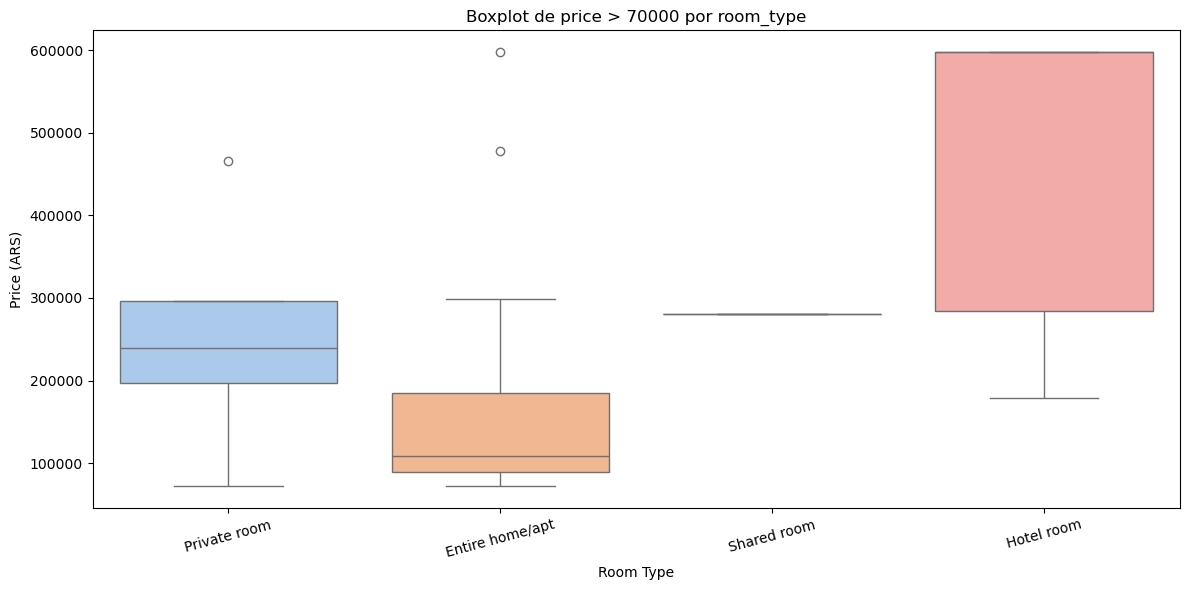

In [150]:
df_filtrado = df[df['price'] > 70000]

fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(data=df_filtrado, x='room_type', y='price', ax=ax, 
            palette='pastel', hue='room_type', legend=False)

ax.set_title('Boxplot de price > 70000 por room_type')
ax.set_xlabel('Room Type')
ax.set_ylabel('Price (ARS)')
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

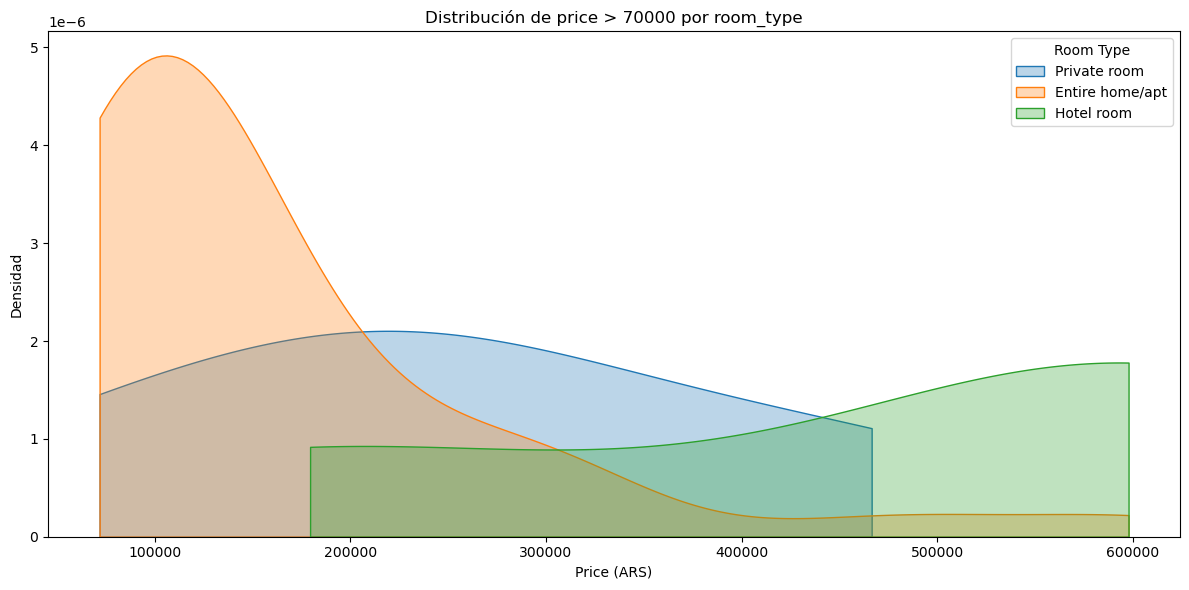

In [151]:
df_filtrado = df[df['price'] > 70000]

fig, ax = plt.subplots(figsize=(12, 6))

for room in df_filtrado['room_type'].unique():
    datos = df_filtrado[df_filtrado['room_type'] == room]['price']
    if len(datos) > 3:  # KDE necesita al menos algunos puntos
        sns.kdeplot(datos, ax=ax, label=room, fill=True, alpha=0.3, cut=0)

ax.set_title('Distribución de price > 70000 por room_type')
ax.set_xlabel('Price (ARS)')
ax.set_ylabel('Densidad')
ax.legend(title='Room Type')

plt.tight_layout()
plt.show()

Vamos a ver que realacion hay entre el precio (99%) y los barrios donde estan ubicados

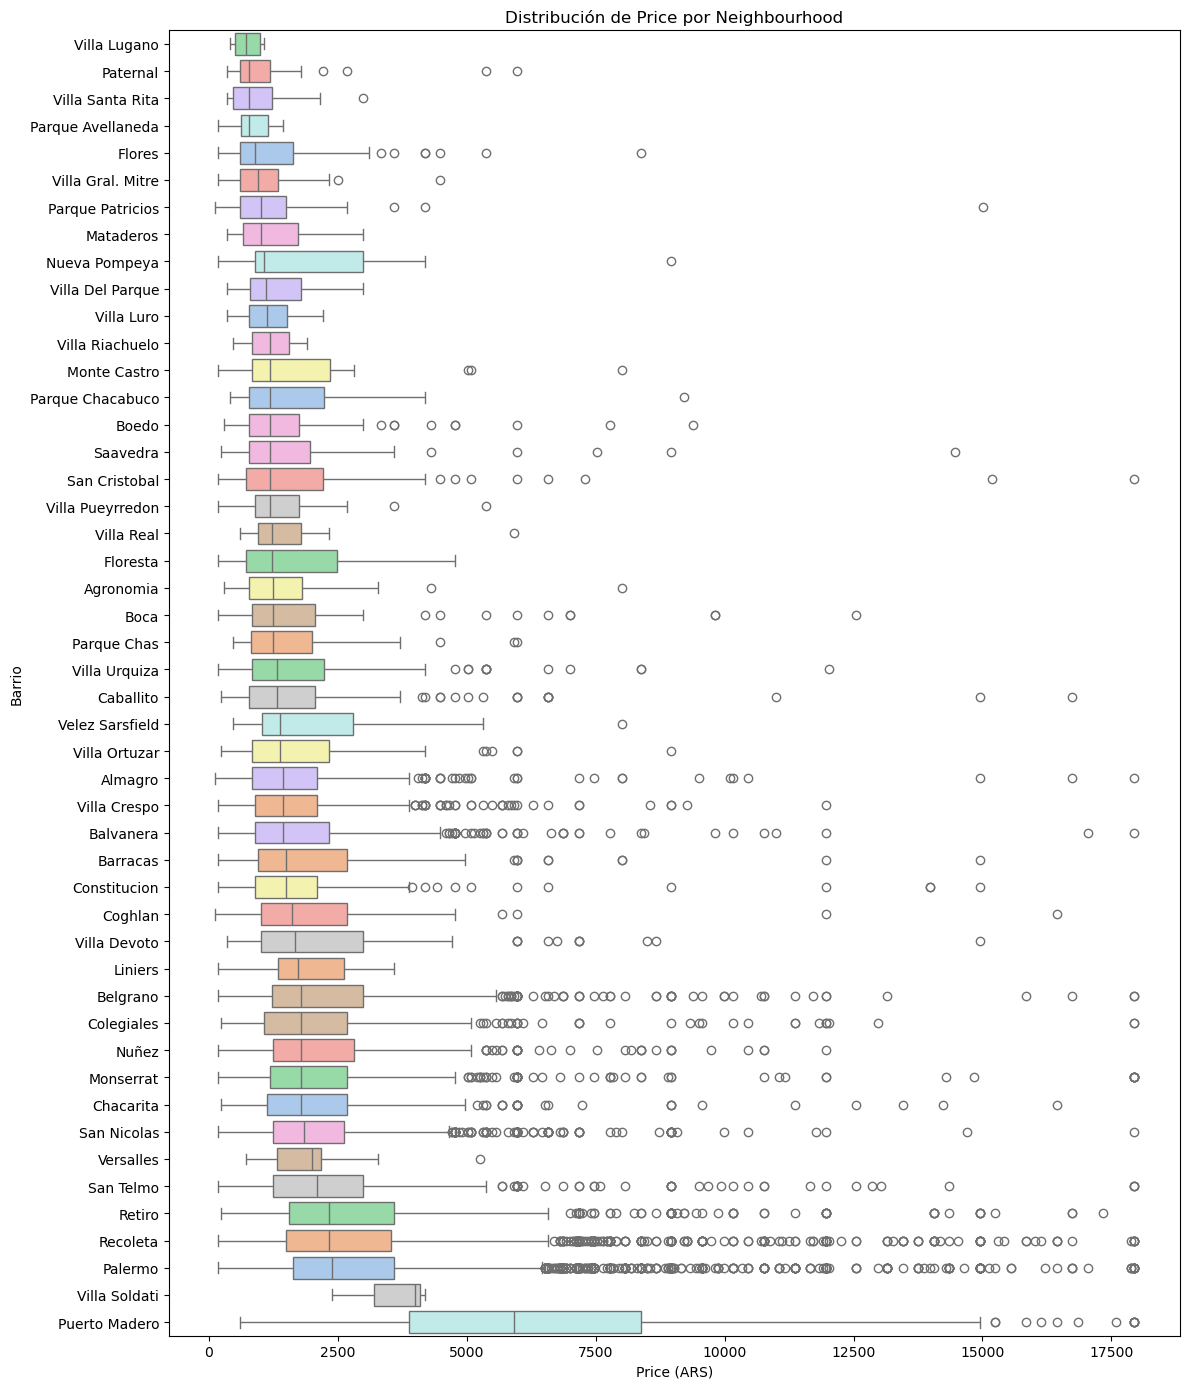

In [152]:
# Filtrar outliers extremos
p99_price = df['price'].quantile(0.99)
df_filtrado = df[df['price'] <= p99_price]

# Ordenar barrios por mediana de precio
orden = df_filtrado.groupby('neighbourhood')['price'].median().sort_values(ascending=True).index

fig, ax = plt.subplots(figsize=(12, 14))

sns.boxplot(data=df_filtrado, y='neighbourhood', x='price', 
            order=orden, ax=ax, palette='pastel',
            hue='neighbourhood', legend=False)

ax.set_title('Distribución de Price por Neighbourhood')
ax.set_xlabel('Price (ARS)')
ax.set_ylabel('Barrio')

plt.tight_layout()
plt.show()

Realizamos el mismo box plot con el 100% de los valores Price y queda totalmente poco identificable

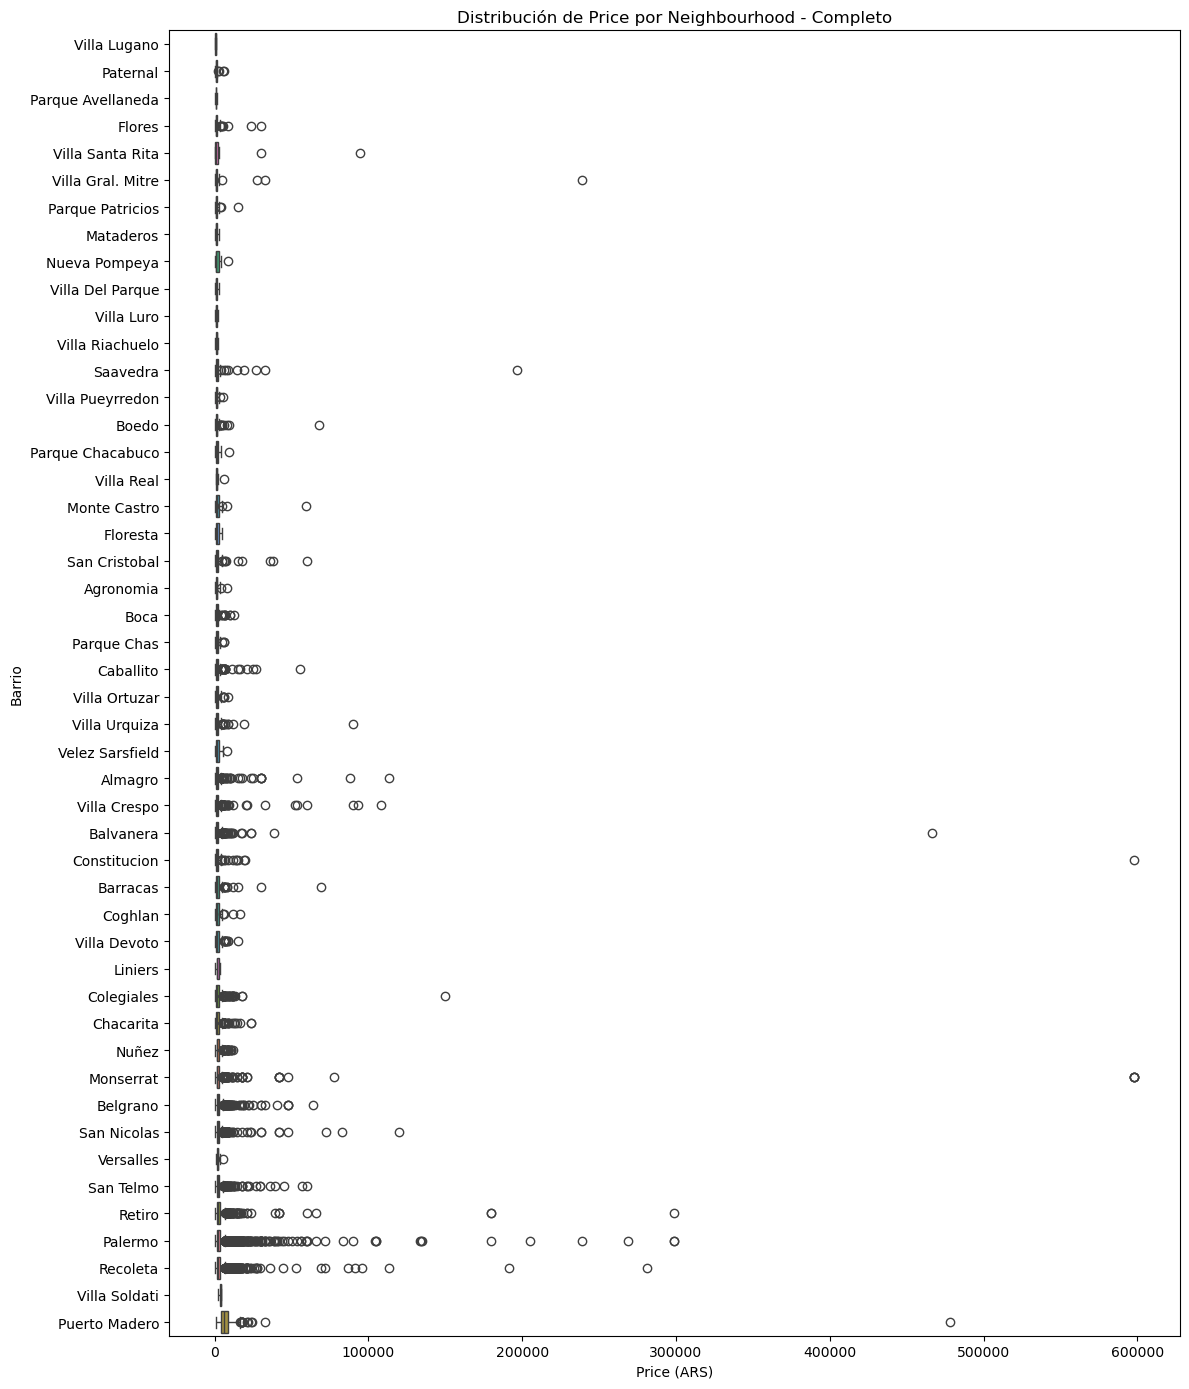

In [153]:
orden = df.groupby('neighbourhood')['price'].median().sort_values(ascending=True).index

fig, ax = plt.subplots(figsize=(12, 14))

sns.boxplot(data=df, y='neighbourhood', x='price',
            order=orden, ax=ax, hue='neighbourhood', legend=False)

ax.set_title('Distribución de Price por Neighbourhood - Completo')
ax.set_xlabel('Price (ARS)')
ax.set_ylabel('Barrio')

plt.tight_layout()
plt.show()